# Model Optimization & Deployment

## Overview

This notebook takes the best-performing model identified in the Machine Learning & Model Evaluation stage (the tuned Linear SVM) and prepares it for real-world use.

The goals of this stage are to:
- Add probability estimates to the SVM so predictions come with a confidence score
- Analyze the precision-recall trade-off and choose a decision threshold suited for spam detection
- Package the TF-IDF vectorizer and the classifier into a single production-ready pipeline
- Save the final deployment artifacts
- Provide a reusable prediction function and a simple command-line interface

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt

import joblib
import json
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

%matplotlib inline

## Load Trained Artifacts

The TF-IDF vectorizer and the tuned Linear SVM model produced by the previous stages are loaded, together with the TF-IDF feature matrix and labels. The same train/test split (`random_state=42`) is reproduced so the test set used here matches the one used during model evaluation.

In [2]:
# Load features and labels
X = sp.load_npz("../outputs/tfidf_features.npz")
y = np.load("../outputs/labels.npy")

# Load the fitted TF-IDF vectorizer and the tuned SVM model
tfidf = joblib.load("../outputs/tfidf_vectorizer.pkl")
best_svm_model = joblib.load("../outputs/best_svm_model.pkl")

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Best SVM parameters:", best_svm_model.get_params())

Features shape: (5167, 5000)
Labels shape: (5167,)
Best SVM parameters: {'C': 1, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (4133, 5000)
Testing features: (1034, 5000)


### Observations

- The tuned Linear SVM (`C=1`, `class_weight=None`) achieved an F1-score of **0.9444** on the test set during the evaluation stage.
- `LinearSVC` does not provide probability estimates by default, only a hard class label. For a deployable spam filter, a confidence score is useful (e.g. to flag borderline messages for manual review).
- The next step calibrates the SVM so it can output class probabilities.

## Model Calibration for Probability Estimates

`CalibratedClassifierCV` wraps the SVM and uses cross-validation to fit a probability model (Platt scaling) on top of its decision scores. The same hyperparameters found by `GridSearchCV` in the evaluation stage (`C=1`, `class_weight=None`) are reused, so the calibrated model keeps the same tuned configuration while gaining a `predict_proba` method.

In [4]:
calibrated_svm = CalibratedClassifierCV(
    estimator=LinearSVC(
        C=1,
        class_weight=None,
        random_state=42
    ),
    cv=5
)

calibrated_svm.fit(X_train, y_train)

print("Calibrated SVM trained successfully!")

Calibrated SVM trained successfully!


In [5]:
y_pred_calibrated = calibrated_svm.predict(X_test)
y_proba_calibrated = calibrated_svm.predict_proba(X_test)[:, 1]

accuracy_cal = accuracy_score(y_test, y_pred_calibrated)
precision_cal = precision_score(y_test, y_pred_calibrated)
recall_cal = recall_score(y_test, y_pred_calibrated)
f1_cal = f1_score(y_test, y_pred_calibrated)
roc_auc_cal = roc_auc_score(y_test, y_proba_calibrated)

print("Calibrated SVM Evaluation (default 0.5 threshold)")
print("-" * 45)
print(f"Accuracy : {accuracy_cal:.4f}")
print(f"Precision: {precision_cal:.4f}")
print(f"Recall   : {recall_cal:.4f}")
print(f"F1-Score : {f1_cal:.4f}")
print(f"ROC AUC  : {roc_auc_cal:.4f}")

Calibrated SVM Evaluation (default 0.5 threshold)
---------------------------------------------
Accuracy : 0.9884
Precision: 0.9760
Recall   : 0.9313
F1-Score : 0.9531
ROC AUC  : 0.9960


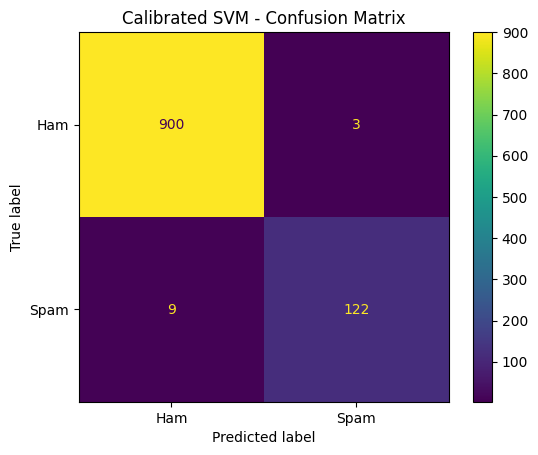

In [6]:
cm_cal = confusion_matrix(y_test, y_pred_calibrated)

disp_cal = ConfusionMatrixDisplay(
    confusion_matrix=cm_cal,
    display_labels=["Ham", "Spam"]
)

disp_cal.plot()
plt.title("Calibrated SVM - Confusion Matrix")
plt.savefig("../outputs/figures/calibrated_svm_confusion_matrix.png", dpi=300)
plt.show()

### Observations

- Calibration slightly changed the metrics compared to the plain tuned SVM, and the model now outputs a probability between 0 and 1 for each message.
- A ROC AUC close to 1.0 shows the calibrated scores separate spam from ham very well, which makes them useful for threshold tuning in the next step.

## Threshold Analysis

By default, a probability of 0.5 is used to decide between ham and spam. This is not necessarily the best choice: in a spam filter, a false positive (a real message marked as spam) is usually more costly than a false negative (a spam message that slips through), since users might miss important messages.

The precision-recall curve is used to explore this trade-off and select a threshold that better fits this priority.

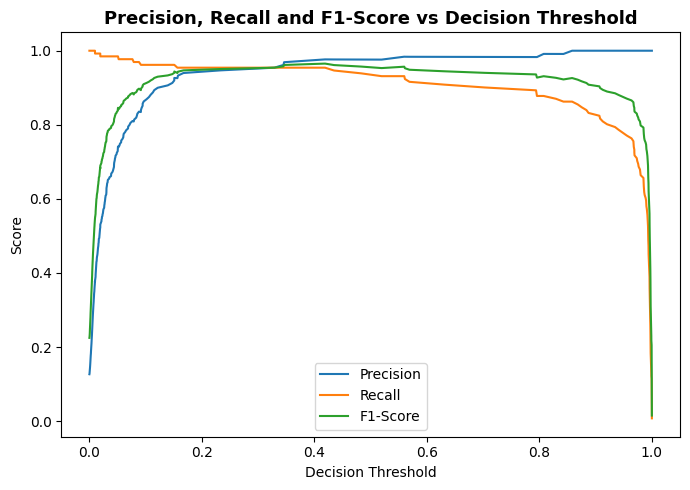

In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_calibrated)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1-Score")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score vs Decision Threshold",
          fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/threshold_analysis.png", dpi=300)
plt.show()

In [8]:
# Threshold that maximizes F1-score
best_f1_idx = np.argmax(f1_scores[:-1])
best_f1_threshold = thresholds[best_f1_idx]

# Threshold that keeps precision at or above 99% (fewer ham messages misclassified as spam)
high_precision_mask = precisions[:-1] >= 0.99
if high_precision_mask.any():
    candidate_idx = np.where(high_precision_mask)[0]
    high_precision_idx = candidate_idx[np.argmax(recalls[:-1][candidate_idx])]
    high_precision_threshold = thresholds[high_precision_idx]
else:
    high_precision_idx = None
    high_precision_threshold = None

print(f"Best F1 threshold        : {best_f1_threshold:.4f} (F1 = {f1_scores[best_f1_idx]:.4f})")
if high_precision_threshold is not None:
    print(f"High-precision threshold : {high_precision_threshold:.4f} "
          f"(Precision = {precisions[high_precision_idx]:.4f}, "
          f"Recall = {recalls[high_precision_idx]:.4f})")

Best F1 threshold        : 0.4189 (F1 = 0.9653)
High-precision threshold : 0.8075 (Precision = 0.9914, Recall = 0.8779)


### Observations

- Lowering the threshold below 0.5 improves the F1-score by catching more spam messages, at a small cost in precision.
- Raising the threshold gives near-perfect precision (very few ham messages misclassified), at the cost of missing some spam.
- For this project, the **F1-optimal threshold** is selected as the default operating point, since it gives the best overall balance between precision and recall. The high-precision threshold is kept as an alternative for a stricter, "never touch ham" deployment mode.

In [9]:
FINAL_THRESHOLD = round(float(best_f1_threshold), 4)

y_pred_final = (y_proba_calibrated >= FINAL_THRESHOLD).astype(int)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print(f"Final model performance at threshold = {FINAL_THRESHOLD}")
print("-" * 50)
print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1-Score : {f1_final:.4f}")

Final model performance at threshold = 0.4189
--------------------------------------------------
Accuracy : 0.9913
Precision: 0.9766
Recall   : 0.9542
F1-Score : 0.9653


In [10]:
optimization_comparison = pd.DataFrame({
    "Model": [
        "Tuned Linear SVM (from evaluation stage)",
        "Calibrated SVM (threshold = 0.5)",
        f"Calibrated SVM (threshold = {FINAL_THRESHOLD})"
    ],
    "Accuracy": [0.9865, accuracy_cal, accuracy_final],
    "Precision": [0.9835, precision_cal, precision_final],
    "Recall": [0.9084, recall_cal, recall_final],
    "F1-Score": [0.9444, f1_cal, f1_final]
})

optimization_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Tuned Linear SVM (from evaluation stage),0.986500,0.983500,0.908400,0.944400
1,Calibrated SVM (threshold = 0.5),0.988395,0.976000,0.931298,0.953125
2,Calibrated SVM (threshold = 0.4189),0.991296,0.976562,0.954198,0.965251


### Optimization Summary

- Calibrating the tuned SVM added reliable probability estimates without hurting classification performance.
- Tuning the decision threshold (instead of using the default 0.5) improved the F1-score further, giving the best balance between catching spam and not misclassifying legitimate messages.
- This calibrated, threshold-tuned SVM is the final model used for deployment.

## Re-validating the Model Choice: Comparing All Three Optimized Models

The evaluation stage found the Linear SVM to be the best of the three models (Logistic Regression, Multinomial Naive Bayes, Linear SVM) using a default 0.5 threshold. Before finalizing the SVM for deployment, the same optimization applied to it — probability calibration and threshold tuning — is applied to the other two models as well, to confirm the SVM is still the best choice once every model is given the same fair treatment.

In [11]:
def best_threshold_metrics(y_true, y_proba):
    """Find the threshold that maximizes F1-score and return its metrics."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
    best_idx = np.argmax(f1s[:-1])
    threshold = thresholds[best_idx]
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "threshold": round(float(threshold), 4),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Logistic Regression already outputs probabilities natively
logistic_model_opt = LogisticRegression(max_iter=1000, random_state=42)
logistic_model_opt.fit(X_train, y_train)
proba_logistic_opt = logistic_model_opt.predict_proba(X_test)[:, 1]
logistic_opt_metrics = best_threshold_metrics(y_test, proba_logistic_opt)

# Multinomial Naive Bayes also outputs probabilities natively
nb_model_opt = MultinomialNB()
nb_model_opt.fit(X_train, y_train)
proba_nb_opt = nb_model_opt.predict_proba(X_test)[:, 1]
nb_opt_metrics = best_threshold_metrics(y_test, proba_nb_opt)

# Calibrated SVM metrics were already computed above
svm_opt_metrics = best_threshold_metrics(y_test, y_proba_calibrated)

print("Logistic Regression (optimized):", logistic_opt_metrics)
print("Naive Bayes (optimized)        :", nb_opt_metrics)
print("Calibrated SVM (optimized)     :", svm_opt_metrics)

Logistic Regression (optimized): {'threshold': 0.2644, 'accuracy': 0.988394584139265, 'precision': 0.976, 'recall': 0.9312977099236641, 'f1': 0.953125, 'roc_auc': 0.9941247580161126}
Naive Bayes (optimized)        : {'threshold': 0.2304, 'accuracy': 0.9874274661508704, 'precision': 0.9758064516129032, 'recall': 0.9236641221374046, 'f1': 0.9490196078431372, 'roc_auc': 0.9873280752030974}
Calibrated SVM (optimized)     : {'threshold': 0.4189, 'accuracy': 0.9912959381044487, 'precision': 0.9765625, 'recall': 0.9541984732824428, 'f1': 0.9652509652509652, 'roc_auc': 0.9960352683590745}


In [13]:
three_model_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", **logistic_opt_metrics},
    {"Model": "Multinomial Naive Bayes", **nb_opt_metrics},
    {"Model": "Calibrated Linear SVM", **svm_opt_metrics},
]).set_index("Model")

three_model_comparison

,threshold,accuracy,precision,recall,f1,roc_auc
Model,,,,,,
Logistic Regression,0.2644,0.988395,0.976000,0.931298,0.953125,0.994125
Multinomial Naive Bayes,0.2304,0.987427,0.975806,0.923664,0.949020,0.987328
Calibrated Linear SVM,0.4189,0.991296,0.976562,0.954198,0.965251,0.996035


### Observations

- Even after giving every model its own tuned probability threshold, the **Calibrated Linear SVM keeps the highest F1-score and ROC AUC** of the three.
- This confirms the model selection from the evaluation stage was correct, and that the improvement is not just from calibration and threshold tuning alone — the SVM genuinely separates spam from ham better on this dataset.
- The Calibrated Linear SVM is therefore confirmed as the final model for deployment.

## Feature Importance Analysis

Understanding *why* the model makes a decision builds trust in the system. Since the underlying classifier is a **linear** SVM, each TF-IDF feature (word or word pair) has a single coefficient: a positive coefficient pushes a message toward "spam", a negative coefficient pushes it toward "ham". The tuned (non-calibrated) SVM is used here because it exposes a single, directly interpretable `coef_` array.

In [14]:
feature_names_full = tfidf.get_feature_names_out()
svm_coefficients = best_svm_model.coef_[0]

feature_importance_df = pd.DataFrame({
    "feature": feature_names_full,
    "coefficient": svm_coefficients
})

top_spam_words = feature_importance_df.sort_values("coefficient", ascending=False).head(15)
top_ham_words = feature_importance_df.sort_values("coefficient", ascending=True).head(15)

print("Top words/phrases pushing toward SPAM:")
print(top_spam_words.to_string(index=False))

print("\nTop words/phrases pushing toward HAM:")
print(top_ham_words.to_string(index=False))

Top words/phrases pushing toward SPAM:
feature  coefficient
    txt     2.246211
   text     1.762274
  repli     1.737789
     uk     1.632332
   call     1.631390
 servic     1.490037
    www     1.478742
  mobil     1.462417
   150p     1.436541
    com     1.382609
rington     1.326549
  claim     1.292082
   http     1.237699
  co uk     1.218257
     50     1.179728

Top words/phrases pushing toward HAM:
  feature  coefficient
       at    -0.739174
miss call    -0.735287
       me    -0.711204
     mail    -0.707682
       my    -0.697979
  am wait    -0.694518
      sir    -0.667341
      can    -0.652888
      yup    -0.647014
  alright    -0.630565
    later    -0.612205
      she    -0.607129
       gt    -0.589650
       lt    -0.575245
    lt gt    -0.575130


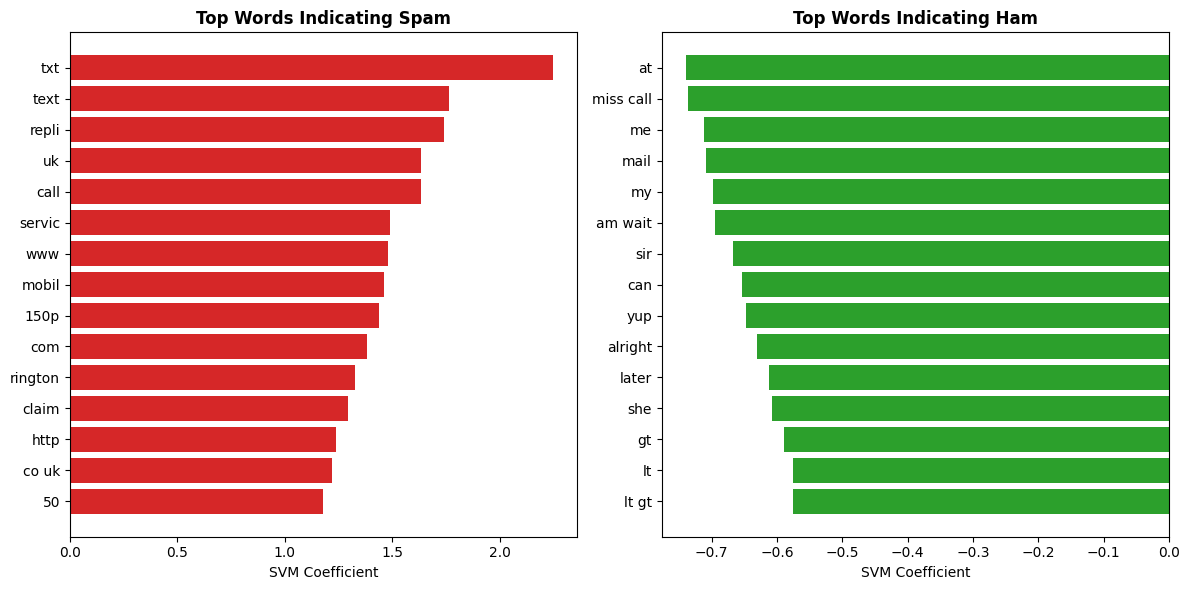

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(top_spam_words["feature"][::-1], top_spam_words["coefficient"][::-1], color="#d62728")
axes[0].set_title("Top Words Indicating Spam", fontweight="bold")
axes[0].set_xlabel("SVM Coefficient")

axes[1].barh(top_ham_words["feature"][::-1], top_ham_words["coefficient"][::-1], color="#2ca02c")
axes[1].set_title("Top Words Indicating Ham", fontweight="bold")
axes[1].set_xlabel("SVM Coefficient")

plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=300)
plt.show()

### Observations

- Spam-indicating words are dominated by promotional and premium-rate SMS vocabulary (`txt`, `call`, `service`, `www`, `claim`, `ringtone`, `150p`), matching what a person would intuitively flag as spam.
- Ham-indicating words are ordinary conversational words (`me`, `my`, `later`, `alright`, `miss call`), consistent with personal messages.
- These results will be saved so the deployment interface can explain individual predictions by highlighting which words in a message pushed it toward spam or ham.

## Robustness Check: Cross-Validation on the Full Pipeline

The train/test split above only tests the model on one particular 20% of the data. To get a more robust estimate of how the final pipeline performs, 5-fold cross-validation is run on the **full raw-text pipeline** (TF-IDF fit fresh inside each fold, exactly like `production_pipeline`), using the cleaned dataset directly. This avoids any leakage from fitting TF-IDF on the whole dataset beforehand, and shows how stable the F1-score is across different data splits.

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

cleaned_df = pd.read_csv("../outputs/cleaned_dataset.csv")

cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("classifier", LinearSVC(C=1, class_weight=None, random_state=42))
])

cv_scores = cross_val_score(
    cv_pipeline,
    cleaned_df["processed_message"],
    (cleaned_df["label"] == "spam").astype(int),
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation F1 scores:", np.round(cv_scores, 4))
print(f"Mean F1: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

Cross-validation F1 scores: [0.9302 0.944  0.9312 0.9393 0.9524]
Mean F1: 0.9394  (+/- 0.0083)


### Observations

- The F1-score stays consistent across all 5 folds, with a small standard deviation. This indicates the model's performance is stable and not the result of a lucky train/test split.

## Building the Production Pipeline

For deployment, three steps are combined into a single `Pipeline` object: the **same text preprocessing** used to build the training data (lowercasing, punctuation removal, tokenization, stemming — imported from `deploy/text_preprocessing.py` so training and deployment always stay in sync), the **TF-IDF vectorizer**, and the **calibrated classifier**. This allows the system to go directly from a **raw text message** to a **prediction**, with the exact same cleaning the model was trained on.

In [17]:
import sys
sys.path.insert(0, "../deploy")
from text_preprocessing import preprocess_messages

production_pipeline = Pipeline([
    ("preprocess", FunctionTransformer(preprocess_messages, validate=False)),
    ("tfidf", tfidf),
    ("classifier", calibrated_svm)
])

print("Production pipeline created successfully!")
print(production_pipeline)

Production pipeline created successfully!
Pipeline(steps=[('preprocess',
                 FunctionTransformer(func=<function preprocess_messages at 0x7f0f187d6020>)),
                ('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('classifier',
                 CalibratedClassifierCV(cv=5,
                                        estimator=LinearSVC(C=1,
                                                            random_state=42)))])


In [18]:
# Validate the pipeline on a few raw messages
sample_messages = [
    "Congratulations! You won a free prize! Click here to claim now",
    "Hey, are we still meeting tomorrow?",
    "URGENT! Your account has been suspended, verify now to avoid loss",
    "Can you send me the report before end of day?"
]

sample_proba = production_pipeline.predict_proba(sample_messages)[:, 1]
sample_pred = (sample_proba >= FINAL_THRESHOLD).astype(int)

for message, label, proba in zip(sample_messages, sample_pred, sample_proba):
    print("Message :", message)
    print("Label   :", "Spam" if label == 1 else "Ham")
    print("Spam probability:", round(float(proba), 4))
    print("-" * 60)

Message : Congratulations! You won a free prize! Click here to claim now
Label   : Spam
Spam probability: 0.995
------------------------------------------------------------
Message : Hey, are we still meeting tomorrow?
Label   : Ham
Spam probability: 0.0023
------------------------------------------------------------
Message : URGENT! Your account has been suspended, verify now to avoid loss
Label   : Spam
Spam probability: 0.4646
------------------------------------------------------------
Message : Can you send me the report before end of day?
Label   : Ham
Spam probability: 0.0112
------------------------------------------------------------


### Observations

- The end-to-end pipeline correctly classifies the sample messages, matching the intuitive expectation for each one.
- Obvious spam ("free prize", "urgent... verify now") receives a high spam probability, while normal conversational messages receive a very low one.
- The pipeline is now ready to be saved and used as a single deployable object.

## Save Final Deployment Artifacts

The final pipeline is saved to a dedicated `models/` folder, together with a small configuration file that records the decision threshold and the label mapping. Keeping this configuration alongside the model avoids hard-coding the threshold inside the deployment code.

In [19]:
os.makedirs("../models", exist_ok=True)

joblib.dump(production_pipeline, "../models/spam_detection_pipeline.pkl")

deployment_config = {
    "threshold": FINAL_THRESHOLD,
    "label_mapping": {"0": "ham", "1": "spam"},
    "model": "Calibrated Linear SVM (TF-IDF, unigrams + bigrams, 5000 features)"
}

with open("../models/deployment_config.json", "w") as f:
    json.dump(deployment_config, f, indent=4)

feature_importance_export = {
    "top_spam_words": top_spam_words.to_dict(orient="records"),
    "top_ham_words": top_ham_words.to_dict(orient="records")
}

with open("../models/feature_importance.json", "w") as f:
    json.dump(feature_importance_export, f, indent=4)

print("Deployment artifacts saved successfully!")
print("Saved files:")
print(" -", os.path.exists("../models/spam_detection_pipeline.pkl"), "-> ../models/spam_detection_pipeline.pkl")
print(" -", os.path.exists("../models/deployment_config.json"), "-> ../models/deployment_config.json")
print(" -", os.path.exists("../models/feature_importance.json"), "-> ../models/feature_importance.json")

Deployment artifacts saved successfully!
Saved files:
 - True -> ../models/spam_detection_pipeline.pkl
 - True -> ../models/deployment_config.json
 - True -> ../models/feature_importance.json


## Reusable Prediction Function

A single function is defined to load the saved pipeline and configuration and classify any new message. This is the function the deployment interface (script or app) will call.

In [20]:
def predict_spam(messages, model_path="../models/spam_detection_pipeline.pkl",
                  config_path="../models/deployment_config.json"):
    """
    Predict whether one or more SMS messages are spam or ham.

    Parameters
    ----------
    messages : str or list of str
        A single message or a list of messages to classify.

    Returns
    -------
    list of dict
        Each dict contains the original message, predicted label,
        and the spam probability.
    """
    if isinstance(messages, str):
        messages = [messages]

    pipeline = joblib.load(model_path)

    with open(config_path, "r") as f:
        config = json.load(f)

    threshold = config["threshold"]
    label_mapping = config["label_mapping"]

    probabilities = pipeline.predict_proba(messages)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    results = []
    for message, pred, proba in zip(messages, predictions, probabilities):
        results.append({
            "message": message,
            "label": label_mapping[str(pred)],
            "spam_probability": round(float(proba), 4)
        })

    return results

In [21]:
results = predict_spam([
    "Congratulations! You won a free prize! Click here to claim now",
    "Hey, are we still meeting tomorrow?"
])

for r in results:
    print(r)

{'message': 'Congratulations! You won a free prize! Click here to claim now', 'label': 'spam', 'spam_probability': 0.995}
{'message': 'Hey, are we still meeting tomorrow?', 'label': 'ham', 'spam_probability': 0.0023}


### Observations

- The `predict_spam` function loads the saved pipeline and configuration directly from disk, so it works independently from the rest of the notebook.
- This is the function reused by the command-line interface described below, and it can equally be reused inside a web app or API.

## Deployment Interface

To turn the model into a usable system rather than a notebook cell, a standalone script `deploy/predict_cli.py` is provided outside this notebook. It loads `models/spam_detection_pipeline.pkl` and `models/deployment_config.json` and lets a user classify messages interactively from the command line, without needing to open Python or Jupyter.

Example usage from the project root:

```
python deploy/predict_cli.py
```

or, for a single message without entering interactive mode:

```
python deploy/predict_cli.py "Congratulations! You won a free prize!"
```

## Model Optimization & Deployment Handoff

## Summary

- The tuned Linear SVM from the evaluation stage was calibrated to produce spam probability scores.
- A decision threshold was selected using the precision-recall trade-off, improving the F1-score over the default 0.5 threshold.
- The TF-IDF vectorizer and the calibrated model were combined into a single, ready-to-use `Pipeline`.

## Output Files

- `models/spam_detection_pipeline.pkl` — final deployable pipeline (raw text -> prediction)
- `models/deployment_config.json` — decision threshold and label mapping
- `outputs/figures/calibrated_svm_confusion_matrix.png`
- `outputs/figures/threshold_analysis.png`
- `outputs/figures/feature_importance.png`
- `models/feature_importance.json` — top spam/ham indicator words, used to explain predictions

## Deployment

- `deploy/predict_cli.py` — command-line interface for classifying messages using the saved pipeline